<h1>MonReader: Single Frame Modelling (SFM): Model Training 2

<h3>Continuing SFM model training

In [2]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"

In [3]:
# Base
import os
import pickle
import numpy as np
import pandas as pd

# Custom
from mrp_functions import *

Load the data, shuffle it, then create validation sets, using the custom functions from the previous notebook for repeatability:

In [4]:
pkl_data = load_pickle_data(SFM_DATA_DIR)

Loaded 5 pickle files:
['sfm_processed_data', 'X_test', 'X_train', 'y_test', 'y_train']


In [5]:
X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

In [6]:
X_train, y_train = shuffle_training_data(X_train, y_train)
X_train, X_val, y_train, y_val = create_validation_set(X_train, y_train)

In [7]:
# Inspect data: 
print("Training Data:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class distribution: {np.bincount(y_train)}")

print("\nValidation Data:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  Class distribution: {np.bincount(y_val)}")

print("\nTest Data:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Class distribution: {np.bincount(y_test)}")

# Inspect pixel value ranges
print("\nPixel value ranges:")
print(f"  X_train: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  X_val: [{X_val.min():.4f}, {X_val.max():.4f}]")
print(f"  X_test: [{X_test.min():.4f}, {X_test.max():.4f}]")

Training Data:
  X_train shape: (1913, 480, 270, 1)
  y_train shape: (1913,)
  Class distribution: [984 929]

Validation Data:
  X_val shape: (479, 480, 270, 1)
  y_val shape: (479,)
  Class distribution: [246 233]

Test Data:
  X_test shape: (597, 480, 270, 1)
  y_test shape: (597,)
  Class distribution: [307 290]

Pixel value ranges:
  X_train: [0.0000, 1.0000]
  X_val: [0.0000, 0.9961]
  X_test: [0.0000, 1.0000]


**'model_1'** from the last notebook had lots of overfitting as shown in the training vs validation loss curves divergence characteristics (see copy below). It's important to address this now.

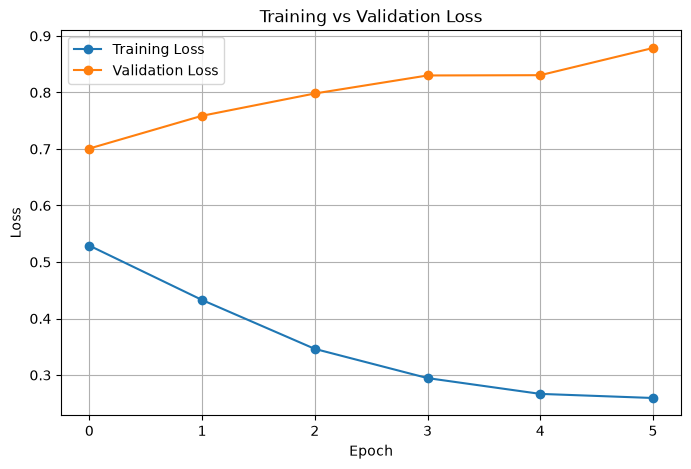

Let's create a new model with tweaks to address this overfitting:

Things to consider when creating the new model:

- **The output layer and loss don't match the problem cleanly**: Using Dense(2, sigmoid), with binary_crossentropy as the loss function, the targets are OneHot encoded despite the fact that we are dealing with a binary problem where the classes are mutually exclusive. Better to treat as binary rather than one hot i.e. [0,1] and [1,0]. Use 0 and 1. May be better to use: Dense(1, activation="sigmoid") with 'binary_crossentropy' for the loss.

- The very immediate overfitting shown in the loss curve is strange. **I don't think it is a pre-processing error** as the same steps are applied to both the train and test set, then randomisation of the train set occurs, followed by a random vaildation split. **Perhaps data augmentation could prove useful.**

- **Can a single frame from a clip show whether a page is being flipped, or are other frames of the same clip required to make the distinction?** Let's inspect some of the images to see if a human could make the distinction.

Quick inspection:

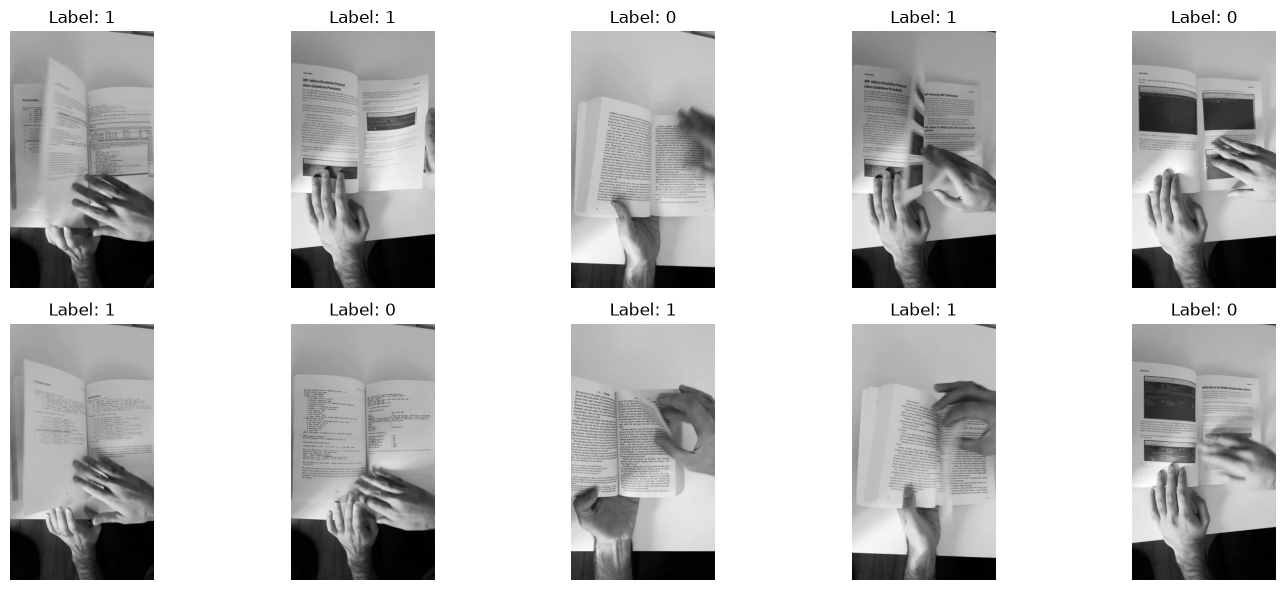

In [8]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = random.sample(range(len(X_train)), 10)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Labels: 0 = notflip, 1 = flip.

As seen in the images there are obvious instances where a page flip is observed and labelled as such. The things that makes a page flip distinct in the images is a *single page mid motion and at-an-angle*. There are a few instances where the way that the human is holding the book at an angle regardless of label which the model could see as a page flip. The key is that the page flip is near the centre of the image and sometimes involves a small covering of the human's hand(s).

**At this stage I think that there is enough information at a single frame level to make a distinction**, we just need to create a model that can do so.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt

In [10]:
train_model_2 = False

In [11]:
if train_model_2 == True:
    # This model looks simpler
    model_2 = Sequential([
        Conv2D(32,3,padding="same",activation="relu",input_shape=X_train.shape[1:]),
        BatchNormalization(),

        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        GlobalAveragePooling2D(),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3), # Increased slightly

        Dense(1, activation="sigmoid") # Changed as mentioned in the first bullet point above.
    ])

    model_2.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall"),
                     tf.keras.metrics.AUC(name="auc")]
            )

    model_2.summary()

    early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=2
            )
    
    # Removed the 'to_categorical' parts as we have implemented Dense(1) above.

    trained_model_2 = model_2.fit(
            X_train,
            y_train,
            batch_size=64, # Batch size can affect training
            epochs=10,
            shuffle=True,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping]
        )
    

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_history.pkl'


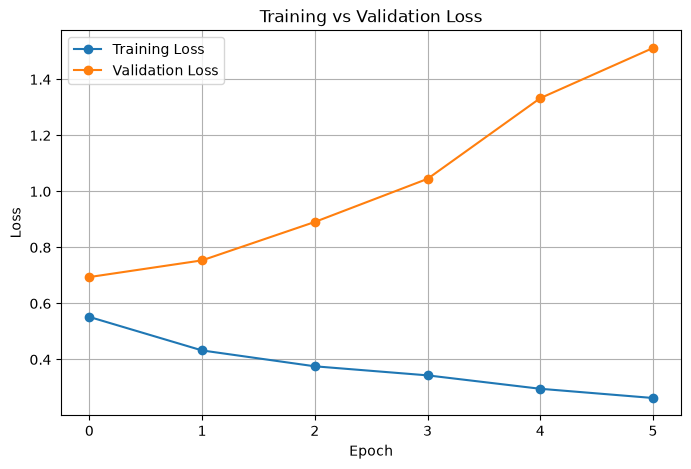

In [12]:
if train_model_2 == False:
    trained_model_2,trained_model_2_history =  load_model("model_2", SFM_MODELS_DIR)
    plot_training_history(trained_model_2_history, metric='loss')
else:
    trained_model_2_history = trained_model_2.history
    plot_training_history(trained_model_2_history, metric='loss')

Make some predictions:

Test set evaluation:
  loss: 0.6933549046516418
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


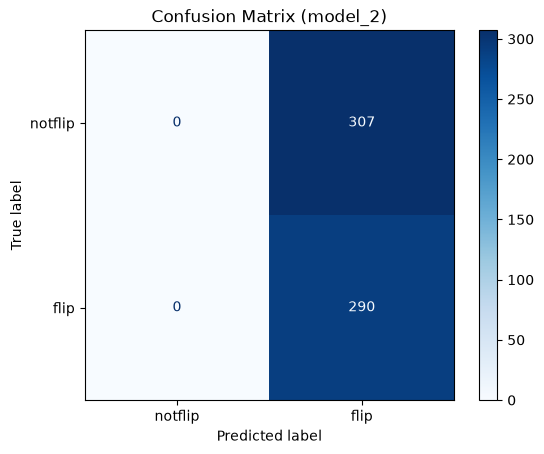

In [13]:
from mrp_functions import evaluate_model

# Logic regarding re-execution without retraining
model_2_to_eval = model_2 if train_model_2 else trained_model_2

eval_results = evaluate_model(
    model_2_to_eval,
    X_test,
    y_test,
    class_names=('notflip', 'flip'),
    plot_name="model_2"
)

Exact same confusion matrix as model_1. 

Save the model:

In [14]:
if train_model_2 == True:
    model_path = SFM_MODELS_DIR / 'model_2' # Don't worry about .pkl or .keras at the end, the function will take care of it.
    save_model(model_path, model_2, model_2.history)

<h3>Image Manipulation to Enhance Image Features

We could apply data augmentation to the data to introduce more feature variance between images which could in theory reduce overfitting.

Another thing we could do is make page/hand/text edges in the images more distinct via modifying the brightness and contrast of the images before data augmentation?

Let's take an example image and apply some enhncements to make the features more distinct:

In [15]:
eg_im = X_train[0]

In [16]:
import cv2

# Single image function with adjustable parameters

#### PLEASE SEE THE UPDATED FUNCTION IN A FEW CELLS AHEAD ####
def enhance_image(image,gamma=0.9,clahe_clip=2.0,clahe_grid=(8, 8),sharpen_amount=0.5):
    """
    Enhance a normalized grayscale image.

    Parameters
    ----------
    image : np.ndarray
        Image of shape (H, W, 1), expected range [0, 1].

    gamma : float
        < 1 brightens image.
        > 1 darkens image.

    CLAHE — Contrast Limited Adaptive Histogram Equalization

    clahe_clip : float
        Strength of local contrast enhancement.

    clahe_grid : tuple
        Size of local regions used by CLAHE.

    sharpen_amount : float
        Strength of unsharp masking.

    Returns
    -------
    np.ndarray
        Enhanced float32 image in range [0, 1].
    """

    # Remove final channel dimension
    img = np.squeeze(image)
    # Convert [0,1] float -> [0,255] uint8 for OpenCV
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    
    # 1. Gamma / exposure
    img_float = img.astype(np.float32) / 255.0
    img_float = np.power(img_float, gamma)
    img = np.clip(img_float * 255,0,255).astype(np.uint8)

    # 2. Local contrast: CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip,tileGridSize=clahe_grid)
    img = clahe.apply(img)

    # 3. Mild sharpening
    blurred = cv2.GaussianBlur(img,(0, 0),sigmaX=1.0)
    img = cv2.addWeighted(img,1 + sharpen_amount,blurred,-sharpen_amount,0)

    # Convert back to float32 [0,1]
    img = img.astype(np.float32) / 255.0

    return img[..., np.newaxis]

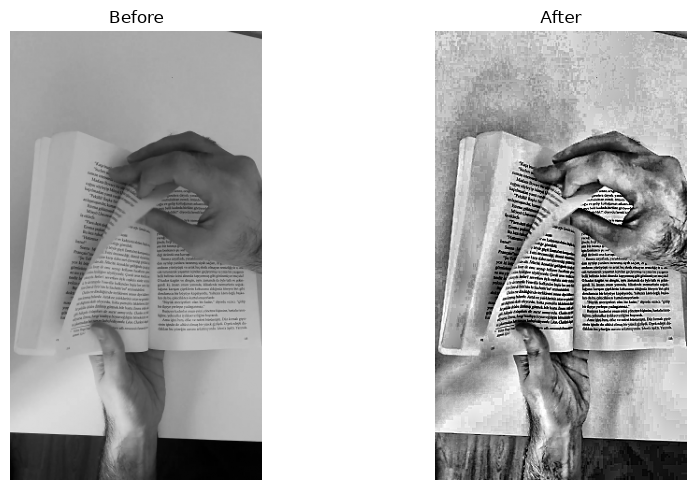

In [17]:
# Enhancement parameters:
gamma = 0.9
clahe_clip = 10.0
clahe_grid = (16,16)
sharpness = 1.0

# Apply enhancements:
mod_eg_im = enhance_image(image = eg_im, gamma=gamma, clahe_clip=clahe_clip, clahe_grid=clahe_grid, sharpen_amount=sharpness)


# Display:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(eg_im.squeeze(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Before")
axes[0].axis("off")

axes[1].imshow(mod_eg_im.squeeze(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("After")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [18]:
print(f"Before: {eg_im.shape}")
print(f"After: {mod_eg_im.shape}")

Before: (480, 270, 1)
After: (480, 270, 1)


In [19]:
# Function to modify whole set:

### SEE ABOVE REGARDING UPDATED FUNCTION ###
def enhance_dataset(X, **kwargs):
    return np.stack([
        enhance_image(image, **kwargs)
        for image in X
    ]).astype(np.float32)

Another way of edge distinction is the use of a **Sobel Filter**. It is a classic image-processing operator used to detect edges by measuring how quickly pixel intensity changes across an image. It monitors changes in pixel value as a function of distance in the x and y directions. Areas of fairly uniform brightness produce values near zero but edges produce high values. 

For this dataset a Sobel image would suppress much of the flat page/background information and highlight things like page edges, text strokes, hand boundaries, folds and page curvature.

In [20]:
eg_im = eg_im.squeeze().astype(np.float32)

sobel_x = cv2.Sobel(eg_im, cv2.CV_32F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(eg_im, cv2.CV_32F, 0, 1, ksize=3)

sobel_im = np.sqrt(sobel_x**2 + sobel_y**2)

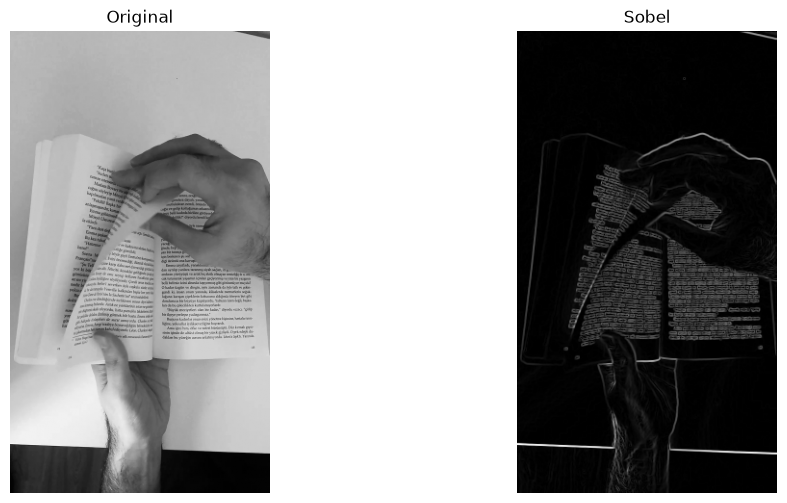

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(eg_im, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sobel_im, cmap="gray")
axes[1].set_title("Sobel")
axes[1].axis("off")

plt.show()

Things like the edges which are now very distinct in the Sobel image, when compared to the original, is what we were aiming for. I don't think we will need to apply the long and drawn-out contrast and exposure processing in the enhance_image() function written above. We can just modify the function to apply the Sobel filter.

Let's update the enhance_image() function and then test it on a random selection of images.

In [22]:
def enhance_image(image):
    """
    Apply Sobel edge detection to a grayscale image.

    Parameters
    ----------
    image : np.ndarray
        Grayscale image with shape (H, W, 1).

    Returns
    -------
    np.ndarray
        Sobel edge-magnitude image with shape (H, W, 1),
        dtype float32 and values normalized to [0, 1].
    
    Example
    -------
    >>> img = X_train[0]
    >>> enh_img = enhance_image(img)
    """

    # Convert (H, W, 1) -> (H, W)
    img = np.squeeze(image).astype(np.float32)

    # Calculate horizontal and vertical intensity gradients
    sobel_x = cv2.Sobel(img,cv2.CV_32F,1,0,ksize=3)

    sobel_y = cv2.Sobel(img,cv2.CV_32F,0,1,ksize=3)

    # Combine x and y gradients into overall edge magnitude
    edges = np.sqrt(sobel_x**2 + sobel_y**2)

    # Normalize to [0, 1]
    max_value = edges.max()

    if max_value > 0:
        edges = edges / max_value

    # Restore channel dimension: (H, W) -> (H, W, 1)
    edges = edges[..., np.newaxis]

    return edges.astype(np.float32)

def enhance_dataset(X):
    """
    Apply Sobel edge detection function, enhance_image(), to every image in a dataset.

    Parameters
    ----------
    X : np.ndarray
        Image dataset with shape (N, H, W, 1).

    Returns
    -------
    np.ndarray
        Sobel-transformed dataset with shape (N, H, W, 1),
        dtype float32 and individual images normalized to [0, 1].
    
    Example
    --------
    >>> X_train_enh = enahnce_dataset(X_train)
    """

    return np.stack([
        enhance_image(image)
        for image in X
    ]).astype(np.float32)

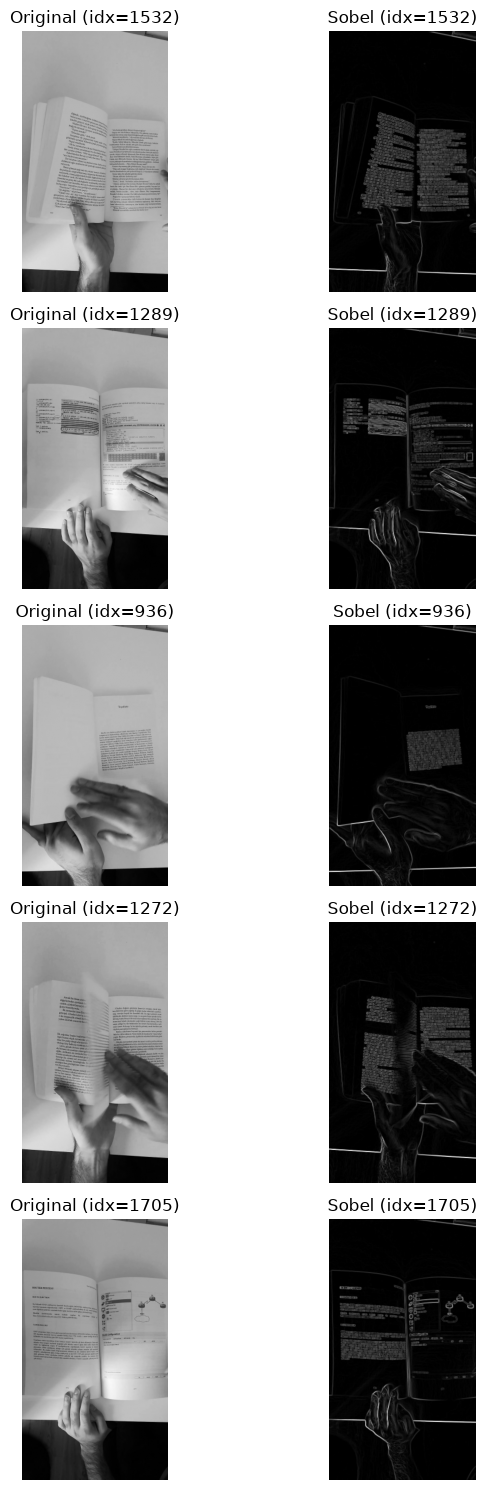

In [23]:
# Randomly select 5 images from X_train
n_samples = 5
sample_indices = np.random.choice(len(X_train), size=n_samples, replace=False)

# Plot before vs after enhancement
fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3 * n_samples))

for row, idx in enumerate(sample_indices):
    original = X_train[idx]
    enhanced = enhance_image(original)

    axes[row, 0].imshow(original.squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"Original (idx={idx})")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(enhanced.squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"Sobel (idx={idx})")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Apply to the whole dataset:

In [24]:
# Load 'fresh' data:

pkl_data = load_pickle_data(SFM_DATA_DIR)

X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

X_train, y_train = shuffle_training_data(X_train, y_train)

Loaded 5 pickle files:
['sfm_processed_data', 'X_test', 'X_train', 'y_test', 'y_train']


In [25]:
# Apply Sobel enhancement to the complete datasets
X_train_enh = enhance_dataset(X_train)
X_test_enh = enhance_dataset(X_test)

In [26]:
# Create val set:
X_train, X_val, y_train, y_val = create_validation_set(X_train_enh, y_train)

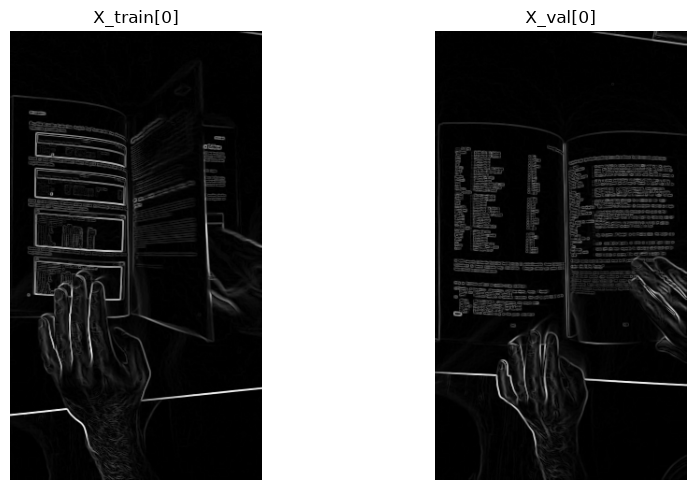

In [27]:
# Display:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(X_train[1].squeeze(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("X_train[0]")
axes[0].axis("off")

axes[1].imshow(X_val[0].squeeze(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("X_val[0]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<h3>Train 'model_2' Replica on the Enhanced Images (model_2_1)

In [28]:
train_model_2_1 = False

In [29]:
if train_model_2_1 == True:
    # This model looks simpler
    model_2_1 = Sequential([
        Conv2D(32,3,padding="same",activation="relu",input_shape=X_train.shape[1:]),
        BatchNormalization(),

        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        GlobalAveragePooling2D(),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3), # Increased slightly

        Dense(1, activation="sigmoid") # Changed as mentioned in the first bullet point above.
    ])

    model_2_1.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall"),
                     tf.keras.metrics.AUC(name="auc")]
            )

    model_2_1.summary()

    early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=2
            )
    
    # Removed the 'to_categorical' parts as we have implemented Dense(1) above.

    trained_model_2_1 = model_2_1.fit(
            X_train,
            y_train,
            batch_size=64, # Batch size can affect training
            epochs=10,
            shuffle=True,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping]
        )
    

In [30]:
if train_model_2_1 == True:
    model_path = SFM_MODELS_DIR / 'model_2_1'
    save_model(model_path, model_2_1, model_2_1.history)

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_1.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_1_history.pkl'


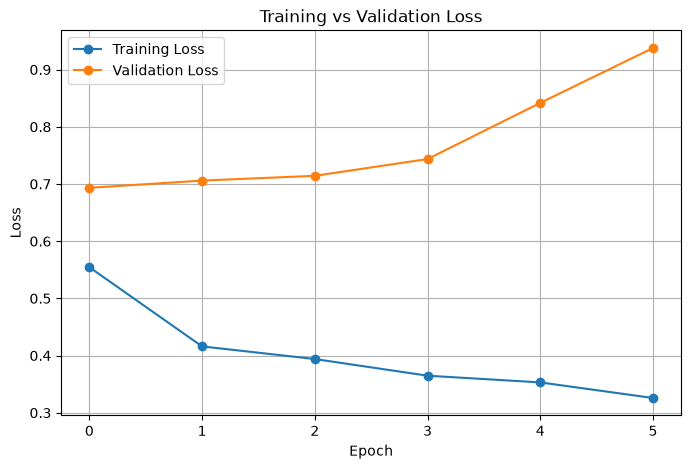

In [31]:
if train_model_2_1 == False:
    trained_model_2_1,trained_model_2_1_history =  load_model("model_2_1", SFM_MODELS_DIR)
    plot_training_history(trained_model_2_1_history, metric='loss')
else:
    trained_model_2_1_history = trained_model_2_1.history
    plot_training_history(trained_model_2_1_history, metric='loss')

Looks better. Still overfitting and struggling to make a distinction between the two classes but it's better than before.

Test set evaluation:
  loss: 0.693241536617279
  compile_metrics: 0.5142378807067871

Classification Report:
              precision    recall  f1-score   support

     notflip       0.51      1.00      0.68       307
        flip       0.00      0.00      0.00       290

    accuracy                           0.51       597
   macro avg       0.26      0.50      0.34       597
weighted avg       0.26      0.51      0.35       597

Macro F1-score: 0.3396


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


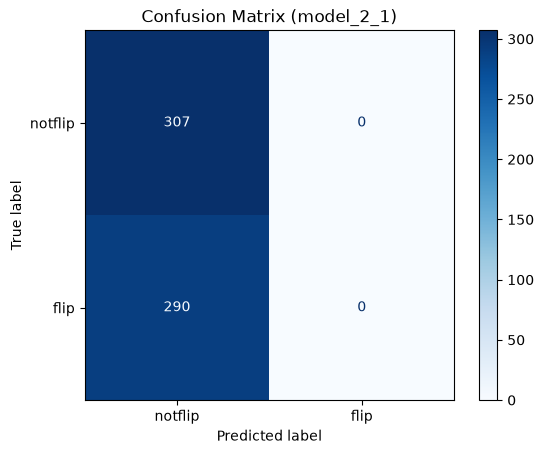

In [32]:
model_2_1_to_eval = model_2_1 if train_model_2_1 else trained_model_2_1

# Guard against accidentally passing the training History object
if isinstance(model_2_1_to_eval, tf.keras.callbacks.History):
    model_2_1_to_eval = model_2_1

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test_enh, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_2_1_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_2_1"
)

In [33]:
if train_model_2_1 == True:
    model_path = SFM_MODELS_DIR / 'model_2_1'
    save_model(model_path, model_2_1, model_2_1.history)

Save the all the processed data (post-Sobel) for future model training simplicity:

In [34]:
processed_data = {
    "X_train": np.asarray(X_train, dtype=np.float32),
    "y_train": np.asarray(y_train),
    "X_val": np.asarray(X_val, dtype=np.float32),
    "y_val": np.asarray(y_val),
    "X_test": np.asarray(X_test_enh, dtype=np.float32),
    "y_test": np.asarray(y_test),
}

processed_data_path = SFM_DATA_DIR / "sfm_processed_data.pkl"

with open(processed_data_path, "wb") as file:
    pickle.dump(processed_data, file)


**I've started to train models on AWS due to local hardware limitations. When training 'model_2_1' on AWS vs local, there is a a major decrease in training time (5-10 fold decrease in time). Going forward model structure will be defined and explained in notebooks and actual training will occur on AWS using an ml.g5.xlarge instance. The trained models/histories will be downloaded to evaluate/test locally. Refer to 'train_sagemaker.py' in the notebooks directory for training script.**

For example, here is the 'model_2_1" above trained on AWS:

In [35]:
print(MODELS_DIR)
print(SFM_MODELS_DIR)

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"

print(SFM_AWS_MODELS_DIR)

job_name = "tensorflow-monreader-model-20260829-132646" #Job name is used as the directory name containing the model and history objects
model_name = "model_2_1_sm.keras" # 'sm' is 'SageMaker' (the AWS service utilised in this work)
history_name = "model_2_1_sm_history.json"

# Because each 'job' / model for AWS has its own directory we'll need to add another directory layer definition

AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name

C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models
C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm
C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained


Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained\tensorflow-monreader-model-20260829-132646\model_2_1_sm.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained\tensorflow-monreader-model-20260829-132646\model_2_1_sm_history.json'


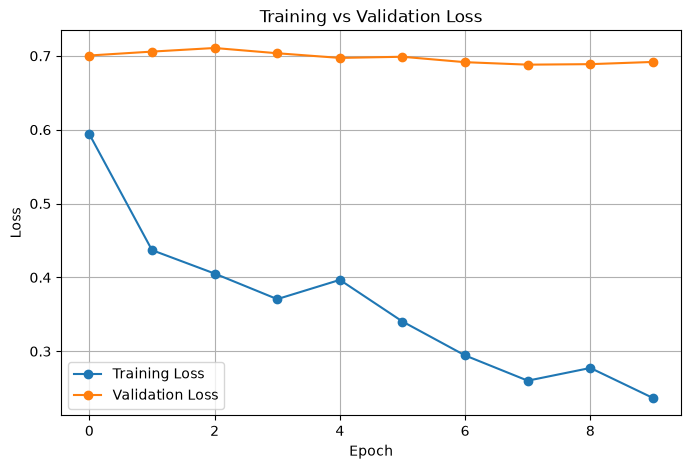

Test set evaluation:
  loss: 0.6900988817214966
  compile_metrics: 0.5142378807067871

Classification Report:
              precision    recall  f1-score   support

     notflip       0.51      0.99      0.68       307
        flip       0.50      0.01      0.02       290

    accuracy                           0.51       597
   macro avg       0.51      0.50      0.35       597
weighted avg       0.51      0.51      0.36       597

Macro F1-score: 0.3487


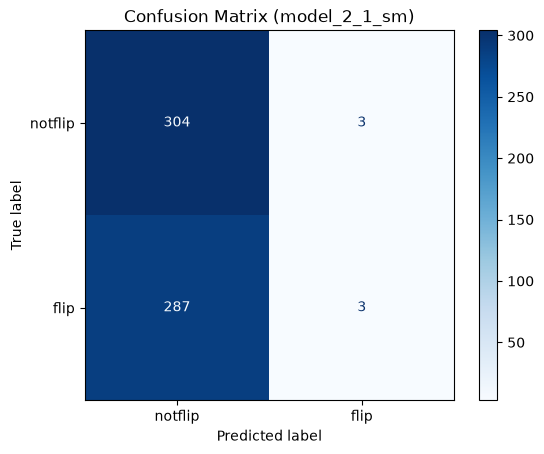

In [36]:
train_model_2_1_sm = False

if train_model_2_1_sm == False:
    aws_trained_model_2_1,aws_trained_model_2_1_history =  load_model("model_2_1_sm", AWS_MODEL_DIR)
    plot_training_history(aws_trained_model_2_1_history, metric='loss')


model_2_1_sm_to_eval = aws_trained_model_2_1 if train_model_2_1_sm == False else model_2_1

# Guard against accidentally passing the training History object
if isinstance(model_2_1_sm_to_eval, tf.keras.callbacks.History):
    model_2_1_sm_to_eval = model_2_1

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test_enh, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_2_1_sm_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_2_1_sm"
)
   

Slightly different end result via AWS probably because early stopping wasn't implemented properly in the 'train_sagemaker.py' script. The CloudWatch logs show no evidence of early_topping 'kicking' into action...

Update: Early-stopping works but need higher epoch count? Not sure why it is different to the locally trained model? Going forward I will be using higher epoch counts...

<h3> Data Augmentation (model_2_2)

Data augmentation can be defined in the model and applied by it randomly during training.

Types of data augmentation to try:


| Augmentation            | Suggested strength | Why useful here                                      |
| ----------------------- | -----------------: | ---------------------------------------------------- |
| Rotation                |              ±2–5° | Camera/book misalignment                             |
| Translation             |             ±5–10% | Book/hand not perfectly centred                      |
| Zoom                    |             ±5–10% | Camera distance variation                            |
| Brightness              |            ±10–15% | Exposure/lighting changes                            |
| Contrast                |            ±10–20% | Different lighting/page reflectance                  |
| Gaussian noise          |         Very small | Sensor/compression noise                             |
| Mild blur               |       Small kernel | Focus/motion variation                               |
| Random crop             |              Small | Prevents reliance on exact pixel locations           |
| Perspective/affine warp |          Very mild | Camera-angle differences                             |
| Random erasing/cutout   |      Small regions | Stops model relying too heavily on one local feature |


Apply data augmentation to the training data only:

In [37]:
data_augmentation = tf.keras.Sequential([
    
    # Small camera/book rotation (~±3.6 degrees)
    tf.keras.layers.RandomRotation(factor=0.01,fill_mode="reflect"),

    # Move image slightly vertically/horizontally
    tf.keras.layers.RandomTranslation(height_factor=0.05,width_factor=0.05,fill_mode="reflect"),

    # Slight variation in camera distance
    tf.keras.layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05), fill_mode="reflect"),

    # Small contrast variation
    tf.keras.layers.RandomContrast(factor=0.10),

    # Simulate small amounts of camera/sensor noise
    tf.keras.layers.GaussianNoise(stddev=0.015)
])

I've left out brightness when working with the Sobel enhanced images because brightness can artificially lift the entire black background.

**Data augmentation is added as a conceptual intermedaite layer between the input and first convolutional layers**

*Trained AWS model below*

In [38]:
train_model_2_2 = False

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained\tensorflow-monreader-model-20260830-181217\model_2_2.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained\tensorflow-monreader-model-20260830-181217\model_2_2_history.json'


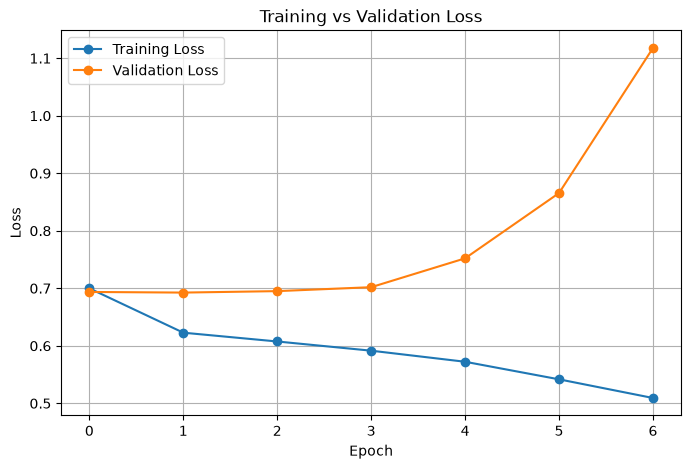

Test set evaluation:
  loss: 0.6927329301834106
  compile_metrics: 0.5142378807067871

Classification Report:
              precision    recall  f1-score   support

     notflip       0.51      1.00      0.68       307
        flip       0.00      0.00      0.00       290

    accuracy                           0.51       597
   macro avg       0.26      0.50      0.34       597
weighted avg       0.26      0.51      0.35       597

Macro F1-score: 0.3396


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


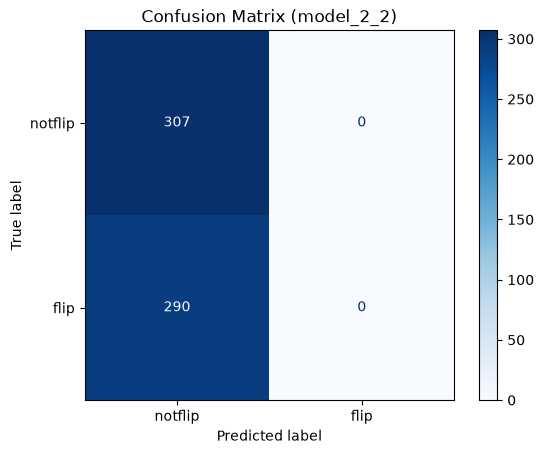

In [40]:
job_name = "tensorflow-monreader-model-20260830-181217" #Job name is used as the directory name containing the model and history objects
model_name = "model_2_2.keras" # 'sm' is 'SageMaker' (the AWS service utilised in this work)
history_name = "model_2_2_history.json"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_2_2 == False:
    model_2_2,model_2_2_history =  load_model("model_2_2", AWS_MODEL_DIR)
    plot_training_history(model_2_2_history, metric='loss')


model_2_2_to_eval = model_2_2 if train_model_2_2 == False else model_2_1

# Guard against accidentally passing the training History object
if isinstance(model_2_2_to_eval, tf.keras.callbacks.History):
    model_2_2_to_eval = model_2_2

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test_enh, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_2_2_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_2_2"
)

The initial divergence is looking better implying that the data augmentation may be helping but it's still not making distinctions. I think I may need to re-think the structure of the model to help it pick out features better.

Doing some research, the design of the CNN may be causing an issue:

- GlobalAveragePooling2D() deliberately discards spatial location. If the distinction between flip and notflip depends on where a hand is, where a page edge lies, how the text is oriented, or the shape of the raised page, throwing away all spatial information may be counterproductive.
- Perhaps the nest step is to alter the structure to remove this.

*In this notebook a distinction via labelling between locally trained and AWS trained models has been made. Going forward assume all models will be trained on AWS. If any models are trained locally a clear label will be applied.*